In [ ]:
import glob
import re
import os.path as op
import os
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

## Define the helpers

In [48]:
def get_file_number(file_name):
    match = re.search(r'outputs_(\d+)', file_name)
    return int(match.group(1)) if match else None


def plot_accuracy_curve(ax, data, filename, method_name, subjects, subject, n_bins, best_bin, n_splits=10, color=None, linewidth=3, alpha=0.1, meth_in_label=False):
    """Handles the mean, SEM calculation, and plotting for a single subject from a given file."""

    n_subjects = len(subjects)
    subject_idx = list(subjects).index(subject)
    n_bins_count = len(n_bins)

    accuracy = np.array(data['accuracy'], dtype=float).reshape(n_bins_count, n_subjects)
    variance = np.array(data['variance'], dtype=float).reshape(n_bins_count, n_subjects)

    mean = accuracy[:, subject_idx]
    sem = variance[:, subject_idx]  / np.sqrt(float(n_splits))

    n_PCs = get_file_number(filename)
    bins = 'bin' if best_bin == 1 else 'bins'
    label = f"{n_PCs} rPCs, {best_bin} {bins}" if method_name == 'rPCA' else f"{n_PCs} gcPCs, {best_bin} {bins}"
    x_axis = np.arange(len(mean))

    upper, lower = mean + sem, mean - sem

    # Plot the main line
    line, = ax.plot(x_axis, mean,
                    label=label,
                    color=color,
                    linewidth=linewidth)
    
    # Plot the shaded SEM area
    ax.fill_between(x_axis,
                    lower,
                    upper,
                    color=line.get_color(),
                    alpha=alpha)
    
    return line.get_color()


def get_best_file_per_subject(file_list, subjects, n_bins_count):
    """Returns a dict {subject: best_filename} where best_filename is the one
    wose PC count yields the highest accuracy across all bins for that subject."""

    n_subjects = len(subjects)
    best_files = {subject: None for subject in subjects}
    best_means = {subject: -1 for subject in subjects}
    best_bins = {subject: None for subject in subjects}

    for file in file_list:
        data = np.load(file, allow_pickle=True).item()
        accuracy = np.array(data['accuracy'], dtype=float)  # shape: (n_bins * n_subjects,)

        # Reshape accuracy to (n_bins, n_subjects) for easier indexing
        accuracy = accuracy.reshape(n_bins_count, n_subjects)
        # Mean across bins per subject
        mean_accuracy_per_subject = np.mean(accuracy, axis=0)  # shape: (n_subjects,)

        for subject_idx, subject in enumerate(subjects):
            if mean_accuracy_per_subject[subject_idx] > best_means[subject]:
                best_means[subject] = mean_accuracy_per_subject[subject_idx]
                best_files[subject] = file
                best_bin_idx = np.argmax(accuracy[:, subject_idx])
                best_bins[subject] = (best_bin_idx + 1, n_bins_count)

    return best_files, best_bins

In [ ]:
data_dir = '../../data/preprocessed_data/'
out_path = '../../data/derivatives/'
output_dir = './Subject-Level_outputs/outputs-1/'
data_files = glob.glob(op.join(data_dir, 'dataClean_step1_*_MED_ON.mat'))
subjects = sorted([x.split('/')[-1].split('_')[3] for x in data_files])
print(subjects)

['s02', 's04', 's05', 's06', 's07', 's08', 's10', 's15', 's16', 's17', 's18']


## Plot the logit accuracies for the best model of the subjects (PCA $\times$ number of bins) across brain regions and PCA

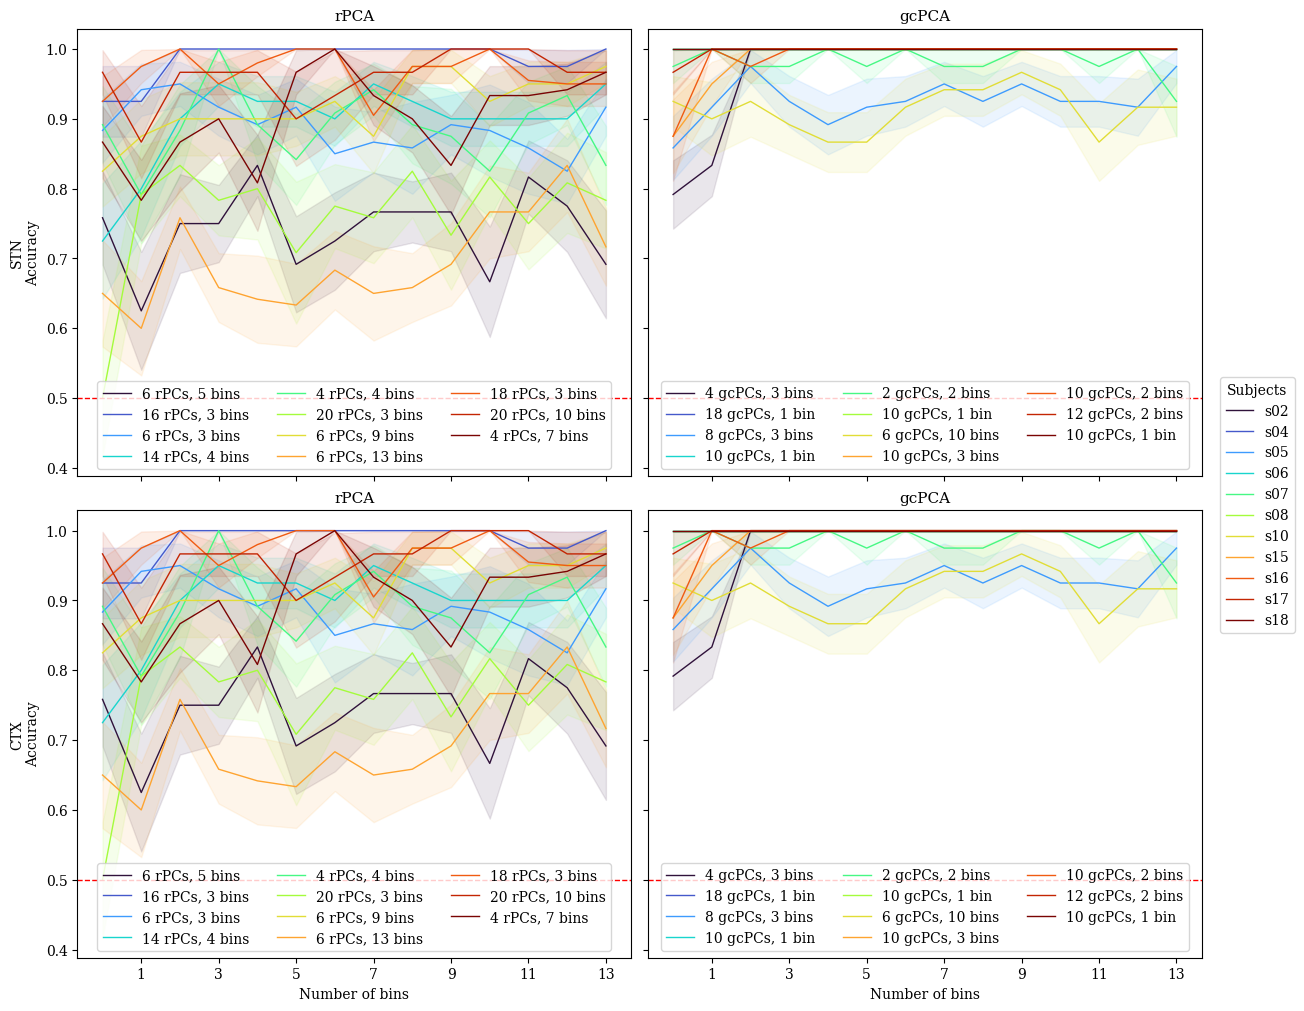

In [62]:
subjects = np.array(subjects)
areas = ['stn', 'ctx']
pca_types = ['rPCA', 'gcPCA']

metadata = np.load(f'{output_dir}metadata.npy', allow_pickle=True).item()
n_bins = metadata['n_bins']
n_bins_count = len(n_bins)

all_files = {}
for pca_type in pca_types:
    for area in areas:
        file_list = sorted([
            op.join(output_dir, f)
            for f in os.listdir(output_dir)
            if f.startswith(pca_type) and f.endswith(f'_{area}.npy')
        ])
        all_files[(pca_type, area)] = file_list

cmap = plt.cm.turbo
colors = {subject: cmap(i / (len(subjects) - 1)) for i, subject in enumerate(subjects)}

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True, constrained_layout=True)

for row_idx, area in enumerate(areas):
    for col_idx, pca_type in enumerate(pca_types):
        ax = axes[row_idx, col_idx]
        file_list = all_files[(pca_type, area)]

        best_files, best_bins = get_best_file_per_subject(file_list, subjects, n_bins_count)  # {subject: best_filename}

        for subject in subjects:
            best_file = best_files[subject]
            data = np.load(best_file, allow_pickle=True).item()
            color = colors[subject]

            plot_accuracy_curve(ax, data, best_file, pca_type,
                                subjects, subject, n_bins,
                                best_bin=int(best_bins[subject][0]),
                                color=color, linewidth=1)
            
        ax.legend(loc='lower center', ncols=3)
        ax.axhline(0.5, color='red', linestyle='--', linewidth=1)
        ax.set_title(f"{pca_type}", fontsize=11)
        ax.set_xlabel("Number of bins") if row_idx == 1 else None
        ax.set_xticks(n_bins[::2])
        ax.set_ylabel(f"{area.upper()}\nAccuracy") if col_idx == 0 else None
        
Legend_handles = [
    plt.Line2D([0], [0], color=colors[subject], lw=1, label=str(subject))
    for subject in subjects
]
fig.legend(handles=Legend_handles, 
           title="Subjects",
           loc='center right',
           bbox_to_anchor=(1.08, 0.5),
           ncol=1,
           fontsize=10,
           frameon=True)

## Plot TF features-based logits across brain regions

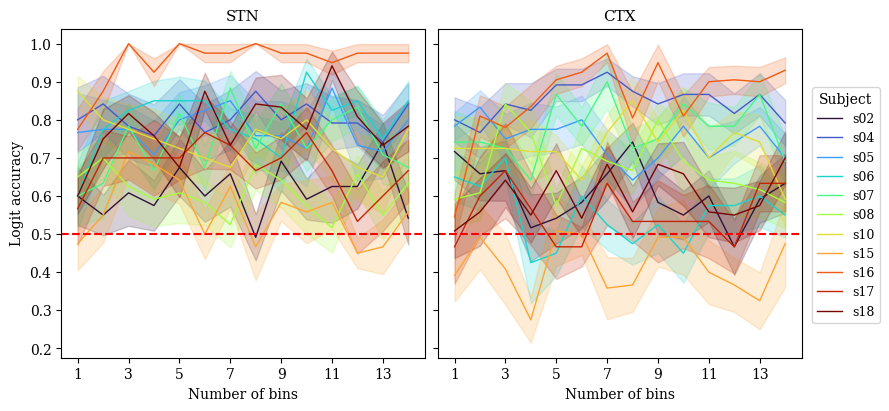

In [59]:
cmap = plt.cm.turbo
colors = {subject: cmap(i / (len(subjects) - 1)) for i, subject in enumerate(subjects)}

areas = ['stn', 'ctx']

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True, constrained_layout=True)

for col_idx, area in enumerate(areas):
    ax = axes[col_idx]
    tf_data = np.load(f'./Subject-Level_outputs/outputs-2/tf_outputs_{area}.npy', allow_pickle=True).item()

    n_bins = tf_data['Metdata']['n_bins']
    n_bins_count = len(n_bins)
    accuracy = np.array(tf_data['accuracy'], dtype=float).reshape(n_bins_count, len(subjects))
    variance = np.array(tf_data['variance'], dtype=float).reshape(n_bins_count, len(subjects))


    for subj_idx, subject in enumerate(subjects):
        mean = accuracy[:, subj_idx]
        sem = variance[:, subj_idx] / np.sqrt(10)

        ax.plot(n_bins, mean, color=colors[subject], lw=1, label=str(subject))
        ax.fill_between(n_bins, mean - sem, mean + sem, color=colors[subject], alpha = 0.2)

    ax.axhline(0.5, color='red', linestyle='--')
    ax.set_xlabel('Number of bins', fontsize=10)
    ax.set_title(f'{area.upper()}', fontsize=11)
    ax.set_xticks(n_bins[::2])

axes[0].set_ylabel('Logit accuracy', fontsize=10)

legend_handles = [
    plt.Line2D([0], [0], color=colors[subject], lw=1, label=str(subject))
    for subject in subjects
]

fig.legend(handles=legend_handles, loc='center right', bbox_to_anchor=(1.10, 0.5),
           fontsize=9, frameon=True, title='Subject')

plt.show()